# Strut and Tie Modelling Demonstration

Follows along the FHWA manual:

Strut-and-Tie Modeling (STM) for Concrete Structures [(FHWA-NHI-17-071)](https://www.fhwa.dot.gov/bridge/concrete/nhi17071.pdf)

## Design Example 1

### Step 1 - Define Model

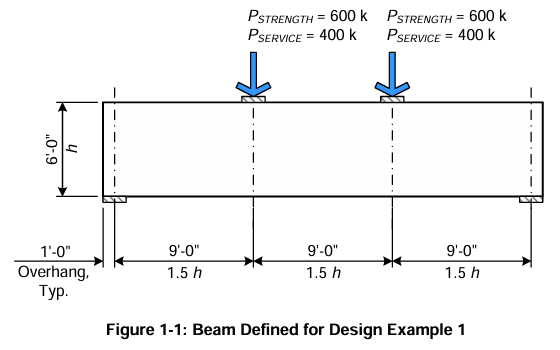

In [2]:
from src.civilpy.structural.strut_and_tie import StrutAndTieModel  # Geometry and statics
from src.civilpy.structural.aashto.lrfd import stm  # Capacity Checks

### Step 2 - Determine B- and D-Regions

Given in AASHTO LRFD Article 5.5.1.2. Refer to AASHTO LRFD Figure 5.5.1.2.1-1

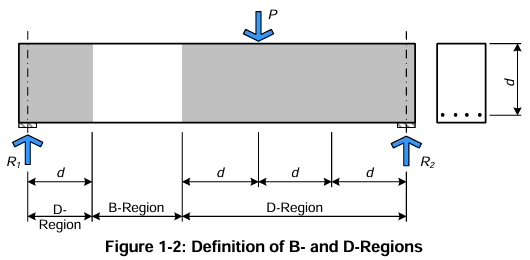

*d* is taken as the effective depth of the member, or the distance from the
extreme compression fiber to the centroid of the tension steel. Note that
the B-Region of this member is the area more than *d* away from from a
disturbance (load, reaction, etc.). In this example, for a member 6' deep,
the distance *d* will be nearly the full height of the member, i.e. *d* and
*h* are essentially the same.

### Step 3 - Define Load Cases

In [2]:
model = StrutAndTieModel()

# Define Nodes
model.add_node("A", 0, 0)
model.add_node("B", 54, 0)
model.add_node("C", 324, 0)
model.add_node("D", 54, 64)
model.add_node("E", 108, 64)
model.add_node("F", 216, 64)

model.add_support("A", fix_x=True, fix_y=True)
model.add_support("C", fix_y=True)

model.add_load("E", fy=-600)
model.add_load("F", fy=-600)

model.add_member("A", "B")
model.add_member("A", "D")
model.add_member("B", "C")
model.add_member("B", "D")
model.add_member("D", "E")
model.add_member("B", "E")
model.add_member("E", "F")
model.add_member("C", "F")

# 5. Add Dummy Member for Matrix Stability
model.add_member("C", "E")

#### Alternative: model in Rhino, analyze here

Calling `add_node` / `add_support` / `add_load` by hand is tedious for real
geometry. Instead, draw the truss in Rhino, tag the supports and loads, and read
it in a single call. The file `NHI17071_Ex_1_STM.3dm` (next to this notebook) is
this same Example 1 model. The tagging convention — *geometry carries what is
spatial, tags carry what is scalar* — is documented in
`docs/Rhino Design Philosophy.md`.

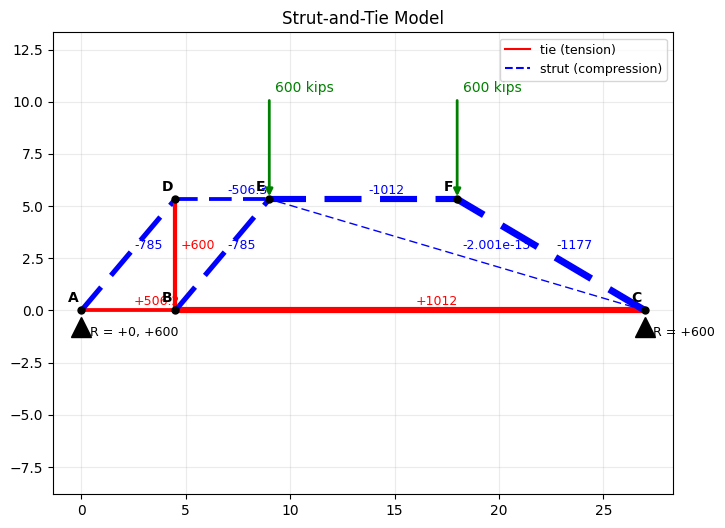

In [3]:
# ...or import the exact same model straight from a Rhino .3dm file.
# Members, supports, and loads are read from object tags (see
# docs/Rhino Design Philosophy.md). Nodes are derived from the member endpoints
# and auto-labeled A, B, C... ordered like an elevation, so this one line
# replaces every add_node / add_support / add_load call above.
model = StrutAndTieModel.from_3dm("NHI17071_Ex_1_STM.3dm")
model.plot();

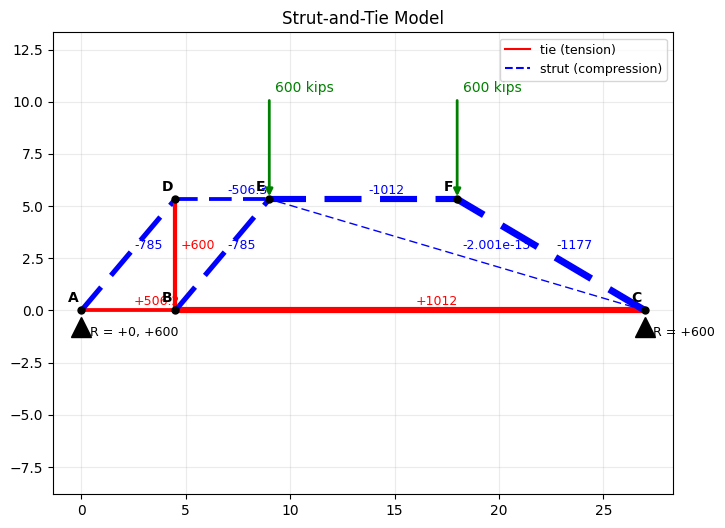

In [4]:
model.plot();
# //TODO - Calculate angles and display them like the example document does for
# Verifying they don't exceed the requirements/minimums

In [5]:
from civilpy.structural.aashto.lrfd.stm import stm_tie_resistance
from civilpy.structural.steel import Rebar

# Make sure the model is solved so we can access the forces
forces = model.forces

# ---------------------------------------------------------
# 1. Proportion the Bottom Tie
# ---------------------------------------------------------
# The maximum force in the bottom chord is in member B-C (1,013 kips)
bottom_tie_demand = forces[("B", "C")]

# The FHWA manual uses 16 No. 10 bars for this tie (Area = 20.32 in^2)
bottom_tie_check = stm_tie_resistance(
    a_st=Rebar(10).area.magnitude * 16,
    f_y=60.0,
    p_u=bottom_tie_demand
)

print("--- Bottom Tie Check ---")
print(f"Demand: {bottom_tie_demand:.1f} kips")
print(f"Capacity: {bottom_tie_check.capacity:.1f} kips")
print(f"Adequate? {bottom_tie_check.capacity >= bottom_tie_demand}\n")

--- Bottom Tie Check ---
Demand: 1012.5 kips
Capacity: 1219.2 kips
Adequate? True



In [6]:
# ---------------------------------------------------------
# 2. Proportion the Vertical Tie
# ---------------------------------------------------------
# The force in the vertical tie is member B-D (600 kips)
vertical_tie_demand = forces[("B", "D")]

# The FHWA manual spreads the vertical steel out over the "available length"
# It uses 9 sets of double No. 5 stirrups (4 legs total per set).
# Area = 9 stirrups * 4 legs * 0.31 in^2/leg = 11.16 in^2
vertical_tie_check = stm_tie_resistance(
    a_st=9 * 4 * Rebar(5).area.magnitude,
    f_y=60.0,
    p_u=vertical_tie_demand
)

print("--- Vertical Tie Check ---")
print(f"Demand: {vertical_tie_demand:.1f} kips")
print(f"Capacity: {vertical_tie_check.capacity:.1f} kips")
print(f"Adequate? {vertical_tie_check.capacity >= vertical_tie_demand}")

--- Vertical Tie Check ---
Demand: 600.0 kips
Capacity: 669.6 kips
Adequate? True


#### Write the solved model back to Rhino

Round-trip the result for review: ties are colored red, struts blue, with each
member force and the support reactions written as text dots on the
`STM::Results` layer.

In [7]:
from civilpy.structural import rhino_stm

rhino_stm.results_to_3dm(model, "NHI17071_Ex_1_results.3dm")

'NHI17071_Ex_1_results.3dm'

In [4]:
from civilpy.structural.strut_and_tie import StrutAndTieModel
from civilpy.structural.aashto.lrfd import stm

model = StrutAndTieModel()

# 1. Define the Nodal Geometry (x, y in feet)
model.add_node("A", 0.0, 5.0)   # Top of overhang (Girder load application)
model.add_node("B", 0.0, 0.0)   # Bottom of overhang
model.add_node("C", 6.0, 5.0)   # Top of column face (Tension tie anchor)
model.add_node("D", 6.0, 0.0)   # Bottom of column face (Compression strut base)

# 2. Add Boundary Conditions (Column face)
model.add_support("C", fix_x=True, fix_y=True)
model.add_support("D", fix_x=True, fix_y=True)

# 3. Apply the Factored Load
model.add_load("A", fy=-600.0)

# 4. Define the Truss Members
model.add_member("A", "C")  # Top horizontal tension tie
model.add_member("A", "D")  # Main diagonal compression strut
model.add_member("A", "B")  # Vertical member (zero force/construction)
model.add_member("B", "D")  # Bottom horizontal member (zero force/construction)

# 5. Solve the Statics
forces = model.solve()
print("--- FHWA CANTILEVER BENT CAP BENCHMARK ---")
for member, force in forces.items():
    kind = "tie" if force > 1e-6 else ("strut" if force < -1e-6 else "zero member")
    print(f"Member {member}: {force:+8.1f} kips ({kind})")

--- FHWA CANTILEVER BENT CAP BENCHMARK ---
Member ('A', 'C'):   +720.0 kips (tie)
Member ('A', 'D'):   -937.2 kips (strut)
Member ('A', 'B'):     +0.0 kips (zero member)
Member ('B', 'D'):     +0.0 kips (zero member)


In [5]:
# 1. Validate Tie Resistance (AASHTO 5.8.2.4)
# Demand from Member A-C. Design requires providing enough steel to carry the tie force.
tie_demand = forces[("A", "C")]
# Using 12 #10 bars (Area = 15.24 sq in) at 60 ksi yield
tie = stm.stm_tie_resistance(a_st=15.24, f_y=60.0, p_u=tie_demand)

print("1. TOP TENSION TIE (Member A-C)")
print(f"Factored Capacity: {tie.factored_capacity:.1f} kips (Expected > {tie_demand:.1f})")
print(f"Status: {'PASS' if tie.factored_capacity >= tie.demand else 'FAIL'}\n")


# 2. Validate Nodal Zone Stresses (AASHTO 5.8.2.5)
# Check Node A: A CCT node where the tension tie and diagonal strut meet the bearing plate.
# Standard design procedures require checking that nodal strengths are greater than the forces acting on the nodes.
node_demand = 600.0  # Vertical bearing demand
# Bearing plate area = 24 in x 24 in = 576 sq in. Concrete f'c = 5.0 ksi.
node = stm.stm_node_resistance(a_cn=576.0, f_c=5.0, node_type="CCT", p_u=node_demand)

print("2. BEARING NODE A (CCT Classification)")
print(f"Factored Capacity: {node.factored_capacity:.1f} kips (Expected > 600.0)")
print(f"Status: {'PASS' if node.factored_capacity >= node.demand else 'FAIL'}\n")


# 3. Validate Crack Control Reinforcement (AASHTO 5.8.2.6)
# AASHTO requires distributed orthogonal reinforcement.
# Providing #5 bars at 12-inch spacing on each face (0.62 sq in / ft) for a 48-inch wide cap.
mesh = stm.stm_crack_control_reinforcement(
    b_w=48.0,
    s_h=12.0,
    s_v=12.0,
    a_s_horizontal=0.62,
    a_s_vertical=0.62
)

print("3. CRACK CONTROL MESH")
print(f"Governing Ratio: {mesh.capacity:.4f} (Expected >= 0.0030)")
print(f"Status: {'PASS' if mesh.capacity >= mesh.demand else 'FAIL'}")

1. TOP TENSION TIE (Member A-C)
Factored Capacity: 823.0 kips (Expected > 720.0)
Status: PASS

2. BEARING NODE A (CCT Classification)
Factored Capacity: 1411.2 kips (Expected > 600.0)
Status: PASS

3. CRACK CONTROL MESH
Governing Ratio: 0.0011 (Expected >= 0.0030)
Status: FAIL


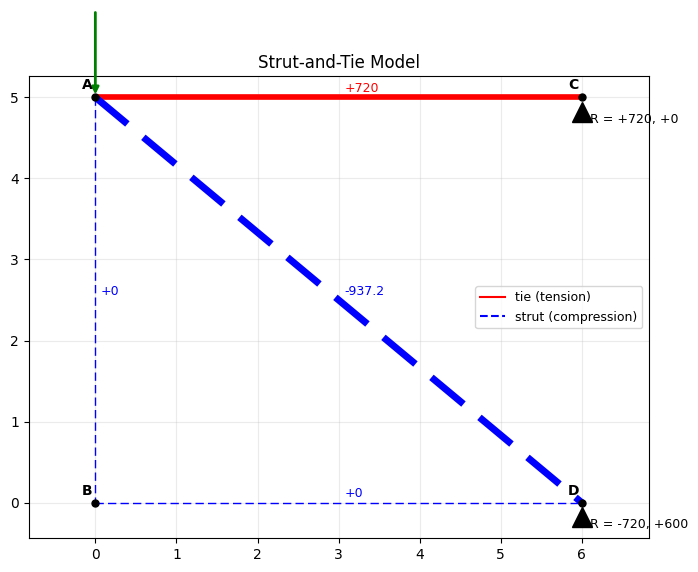

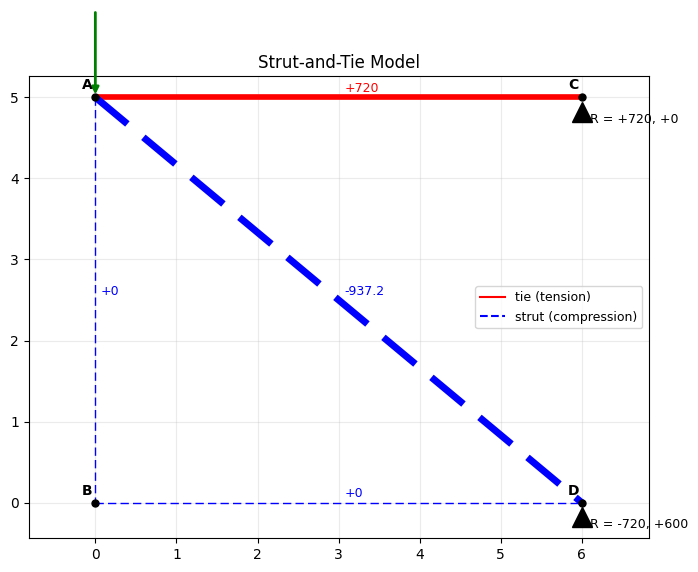

In [6]:
model.plot()